In [28]:

import sys
def noise_corrected(table, undirected = False, return_self_loops = False, calculate_p_value = False):
   sys.stderr.write("Calculating NC score...\n")
   table = table.copy()
   src_sum = table.groupby(by = "src").sum()[["nij"]]
   table = table.merge(src_sum, left_on = "src", right_index = True, suffixes = ("", "_src_sum"))
   trg_sum = table.groupby(by = "trg").sum()[["nij"]]
   table = table.merge(trg_sum, left_on = "trg", right_index = True, suffixes = ("", "_trg_sum"))
   table.rename(columns = {"nij_src_sum": "ni.", "nij_trg_sum": "n.j"}, inplace = True)
   table["n.."] = table["nij"].sum()
   table["mean_prior_probability"] = ((table["ni."] * table["n.j"]) / table["n.."]) * (1 / table["n.."])
   if calculate_p_value:
      table["score"] = binom.cdf(table["nij"], table["n.."], table["mean_prior_probability"])
      return table[["src", "trg", "nij", "score"]]
   table["kappa"] = table["n.."] / (table["ni."] * table["n.j"])
   table["score"] = ((table["kappa"] * table["nij"]) - 1) / ((table["kappa"] * table["nij"]) + 1)
   table["var_prior_probability"] = (1 / (table["n.."] ** 2)) * (table["ni."] * table["n.j"] * (table["n.."] - table["ni."]) * (table["n.."] - table["n.j"])) / ((table["n.."] ** 2) * ((table["n.."] - 1)))
   table["alpha_prior"] = (((table["mean_prior_probability"] ** 2) / table["var_prior_probability"]) * (1 - table["mean_prior_probability"])) - table["mean_prior_probability"]
   table["beta_prior"] = (table["mean_prior_probability"] / table["var_prior_probability"]) * (1 - (table["mean_prior_probability"] ** 2)) - (1 - table["mean_prior_probability"])
   table["alpha_post"] = table["alpha_prior"] + table["nij"]
   table["beta_post"] = table["n.."] - table["nij"] + table["beta_prior"]
   table["expected_pij"] = table["alpha_post"] / (table["alpha_post"] + table["beta_post"])
   table["variance_nij"] = table["expected_pij"] * (1 - table["expected_pij"]) * table["n.."]
   table["d"] = (1.0 / (table["ni."] * table["n.j"])) - (table["n.."] * ((table["ni."] + table["n.j"]) / ((table["ni."] * table["n.j"]) ** 2)))
   table["variance_cij"] = table["variance_nij"] * (((2 * (table["kappa"] + (table["nij"] * table["d"]))) / (((table["kappa"] * table["nij"]) + 1) ** 2)) ** 2) 
   table["sdev_cij"] = table["variance_cij"] ** .5
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table = table[table["src"] <= table["trg"]]
   return table[["src", "trg", "nij", "score", "sdev_cij"]]

In [33]:
# =======================================================
# FINAL: COMMUNITY DETECTION PIPELINE FOR YOUR DATASET
# =======================================================

import pandas as pd
import networkx as nx
from community import community_louvain   # pip install python-louvain

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
airports = pd.read_csv("data/airports.csv")
routes = pd.read_csv("data/routes.csv")

print("Loaded airports:", airports.shape)
print("Loaded routes:", routes.shape)


# ---------------------------------------------------------
# 2. CLEAN AIRPORTS
# ---------------------------------------------------------

# Remove nulls or empty strings in iata_code
airports = airports[
    airports["iata_code"].notna() &
    (airports["iata_code"].str.strip() != "")
]

# Convert ID to int again (since we filtered rows)
airports["id"] = airports["id"].astype(int)

valid_airport_ids = set(airports["id"])

print("Airports with valid IATA:", len(valid_airport_ids))

# Remove rows with missing airport ID
airports = airports[airports["id"].notna()]
airports["id"] = airports["id"].astype(int)

valid_airport_ids = set(airports["id"])
print("Valid airports:", len(valid_airport_ids))


# ---------------------------------------------------------
# 3. CLEAN ROUTES (FINAL FIX)
# ---------------------------------------------------------

# Remove rows where Source or Destination airport ID = "\N" (string)
routes = routes[
    (routes["Source airport ID"] != "\\N") &
    (routes["Destination airport ID"] != "\\N")
]

# Convert to integer AFTER filtering
routes["Source airport ID"] = routes["Source airport ID"].astype(int)
routes["Destination airport ID"] = routes["Destination airport ID"].astype(int)

# Only keep routes with valid airport IDs
routes = routes[
    routes["Source airport ID"].isin(valid_airport_ids) &
    routes["Destination airport ID"].isin(valid_airport_ids)
]

print("Valid routes:", routes.shape)



# ---------------------------------------------------------
# PREPARE ROUTE TABLE FOR NOISE-CORRECTED BACKBONE
# ---------------------------------------------------------

# We need columns: src, trg, nij
# nij = number of routes between src and trg (counts frequency)
route_table = routes.groupby(
    ["Source airport ID", "Destination airport ID"]
).size().reset_index(name="nij")

route_table.rename(
    columns={
        "Source airport ID": "src",
        "Destination airport ID": "trg"
    },
    inplace=True
)

# ---------------------------------------------------------
# RUN NOISE-CORRECTED BACKBONING
# ---------------------------------------------------------

nc = noise_corrected(route_table, undirected=True)

backbone_edges = nc[nc["score"] > 0].copy()

# ---------------------------------------------------------
# BUILD GRAPH USING BACKBONED EDGES
# ---------------------------------------------------------

H = nx.Graph()

# Add airport nodes
for _, row in airports.iterrows():
    H.add_node(
        row["id"],
        iata=row["iata_code"],
        country=row["iso_country"],
        lat=row["latitude_deg"],
        lon=row["longitude_deg"],
        name=row["name"]
    )

# Add NC-backboned edges
for _, row in backbone_edges.iterrows():
    H.add_edge(
        int(row["src"]),
        int(row["trg"]),
        weight=row["nij"],
        score=row["score"]
    )
    

print("Graph built:")
print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())


# ---------------------------------------------------------
# 4. BUILD WEIGHTED GRAPH
# ---------------------------------------------------------

# G = nx.Graph()

# # Add nodes
# for _, row in airports.iterrows():
#     G.add_node(
#         row["id"],
#         iata=row["iata_code"],
#         name=row["name"],
#         country=row["iso_country"],
#         lat=row["latitude_deg"],
#         lon=row["longitude_deg"]
#     )

# # Add weighted edges
# routes["weight"] = 1
# edges = routes.groupby(["Source airport ID", "Destination airport ID"]).size()\
#               .reset_index(name="weight")

# for _, row in edges.iterrows():
#     G.add_edge(
#         row["Source airport ID"],
#         row["Destination airport ID"],
#         weight=row["weight"]
#     )

# print("Graph built with:")
# print("Nodes:", G.number_of_nodes())
# print("Edges:", G.number_of_edges())


# ---------------------------------------------------------
# REMOVE ISOLATED NODES
# ---------------------------------------------------------

isolated = list(nx.isolates(H))   # all nodes with degree 0
print("Isolated nodes:", len(isolated))

H.remove_nodes_from(isolated)
print("Graph after removing isolated nodes:")
print("Nodes:", H.number_of_nodes())
print("Edges:", H.number_of_edges())



# ---------------------------------------------------------
# 5. COMMUNITY DETECTION
# ---------------------------------------------------------

partition = community_louvain.best_partition(H, weight="weight")

# Convert mapping to groups
communities = {}
for node, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(node)

print("\nDetected communities:", len(communities))


# ---------------------------------------------------------
# REMOVE SMALL COMMUNITIES
# ---------------------------------------------------------

MIN_SIZE = 50   # <-- change this to whatever you want

large_communities = {
    cid: nodes for cid, nodes in communities.items()
    if len(nodes) >= MIN_SIZE
}

print(f"Communities before filtering: {len(communities)}")
print(f"Communities after filtering: {len(large_communities)}")

communities = large_communities



# ---------------------------------------------------------
# 6. PRINT COMMUNITIES
# ---------------------------------------------------------

for comm_id, nodes in sorted(communities.items()):
    print("\n=============================")
    print(f"COMMUNITY {comm_id} — size {len(nodes)}")
    print("=============================")

    for n in nodes:
        info = H.nodes[n]
        print(f"- {info['iata']} ({info['name']}, {info['country']})")
        


Loaded airports: (83692, 19)
Loaded routes: (67663, 10)
Airports with valid IATA: 9067
Valid airports: 9067
Valid routes: (25157, 10)


Calculating NC score...


Graph built:
Nodes: 9067
Edges: 6165
Isolated nodes: 7631
Graph after removing isolated nodes:
Nodes: 1436
Edges: 6165

Detected communities: 44
Communities before filtering: 44
Communities after filtering: 7

COMMUNITY 6 — size 202
- HGU (Mount Hagen Kagamuga Airport, PG)
- MAS (Momote Airport, PG)
- WWK (Wewak International Airport, PG)
- JAM (Bezmer Air Base, BG)
- YGZ (Grise Fiord Airport, CA)
- YQC (Quaqtaq Airport, CA)
- YHF (Hearst René Fontaine Municipal Airport, CA)
- YNS (Nemiscau Airport, CA)
- YHI (Ulukhaktok Holman Airport, CA)
- YHK (Gjoa Haven Airport, CA)
- YHN (Hornepayne Municipal Airport, CA)
- YHT (Haines Junction Airport, CA)
- YIB (Atikokan Municipal Airport, CA)
- YDG (Digby / Annapolis Regional Airport, CA)
- YIF (St Augustin Airport, CA)
- YIK (Ivujivik Airport, CA)
- YIV (Island Lake Airport, CA)
- YQA (Muskoka Airport, CA)
- YQD (The Pas Airport, CA)
- YQG (Windsor Airport, CA)
- YQI (Yarmouth Airport, CA)
- YQL (Lethbridge County Airport, CA)
- YQV (Yorkton 

/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/joakimandersen/Downloads/enter/envs/py310/lib/python3.10/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


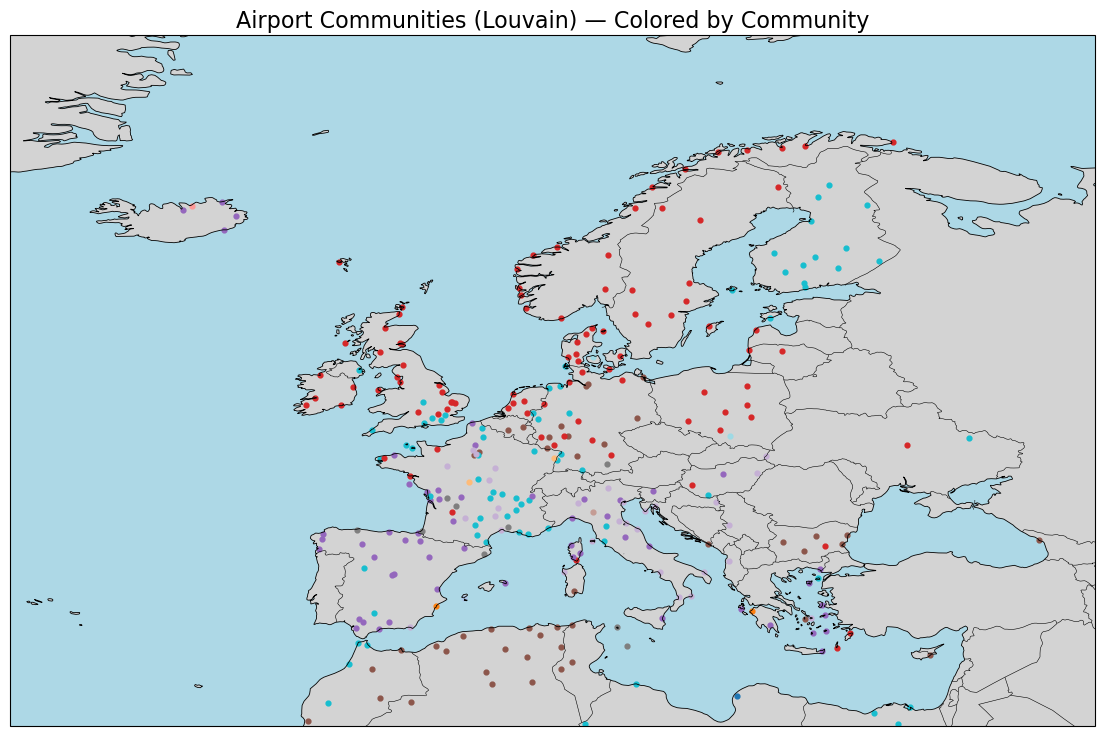

In [34]:
# ======================================================
# PLOT COMMUNITY MAP
# ======================================================

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ------------------------------------------------------
# Convert partition dict (node → community) into colors
# ------------------------------------------------------

# Get unique community IDs
community_ids = sorted(set(partition.values()))

# Generate a color for each community
cmap = plt.get_cmap("tab20")   # 20 distinct colors
color_lookup = {comm_id: cmap(i % 20) for i, comm_id in enumerate(community_ids)}

# ------------------------------------------------------
# Build positions (lon, lat) for plotting
# ------------------------------------------------------

pos = {
    n: (H.nodes[n]["lon"], H.nodes[n]["lat"])
    for n in H.nodes()
    if H.nodes[n]["lon"] is not None and H.nodes[n]["lat"] is not None
}

# ------------------------------------------------------
# Create the map
# ------------------------------------------------------

plt.figure(figsize=(14, 10))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-30, 45, 30, 75])  # Europe + North Atlantic

# Add background map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# ------------------------------------------------------
# Draw edges (light gray so nodes stand out)
# ------------------------------------------------------

# for u, v in G.edges():
#     x1, y1 = pos[u]
#     x2, y2 = pos[v]
#     ax.plot([x1, x2], [y1, y2],
#             color="gray", linewidth=0.2, alpha=0.4,
#             transform=ccrs.PlateCarree())

# ------------------------------------------------------
# Draw nodes colored by community
# ------------------------------------------------------

for node, (lon, lat) in pos.items():
    comm = partition[node]
    ax.scatter(
        lon, lat,
        color=color_lookup[comm],
        s=12,
        alpha=1,
        transform=ccrs.PlateCarree()
    )

plt.title("Airport Communities (Louvain) — Colored by Community", fontsize=16)
plt.show()


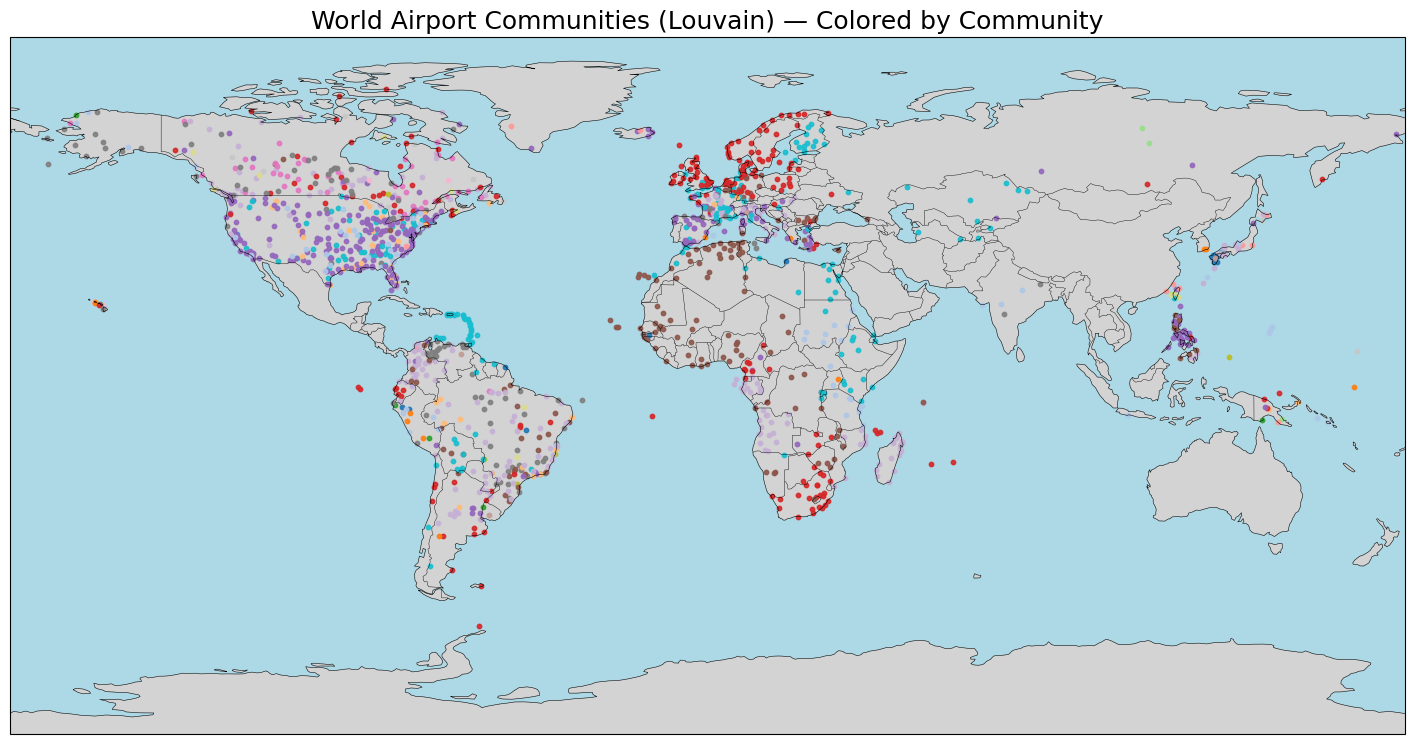

In [37]:
# ======================================================
# WORLD MAP OF AIRPORT COMMUNITIES
# ======================================================

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ------------------------------------------------------
# Create a color lookup for each community
# ------------------------------------------------------

community_ids = sorted(set(partition.values()))
cmap = plt.get_cmap("tab20")  # 20 distinct colors
color_lookup = {cid: cmap(i % 20) for i, cid in enumerate(community_ids)}

# ------------------------------------------------------
# Build pos dictionary of lon/lat for plotting
# ------------------------------------------------------

pos = {}
for n, data in H.nodes(data=True):
    lat = data.get("lat")
    lon = data.get("lon")
    if lat is not None and lon is not None:
        pos[n] = (lon, lat)

# ------------------------------------------------------
# Create WORLD MAP
# ------------------------------------------------------

plt.figure(figsize=(18, 12))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()   # <--- WORLD VIEW

# Background map
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# ------------------------------------------------------
# Draw edges lightly
# ------------------------------------------------------
# for u, v in G.edges():
#     lon1, lat1 = pos[u]
#     lon2, lat2 = pos[v]
#     ax.plot([lon1, lon2], [lat1, lat2],
#             color="gray", linewidth=0.15, alpha=0.35,
#             transform=ccrs.PlateCarree())

# ------------------------------------------------------
# Draw nodes colored by community
# ------------------------------------------------------
for node, (lon, lat) in pos.items():
    comm = partition[node]
    ax.scatter(lon, lat,
               color=color_lookup[comm],
               s=10,
               alpha=0.9,
               transform=ccrs.PlateCarree())

plt.title("World Airport Communities (Louvain) — Colored by Community", fontsize=18)
plt.show()


In [46]:
import pandas as pd
import networkx as nx
from collections import Counter, defaultdict

# ==========================================================
# 1. GROUP NODES BY COMMUNITY
# ==========================================================

# Create dictionary: community_id -> list of nodes
communities = defaultdict(list)
for node, comm in partition.items():
    communities[comm].append(node)

# Sort by community size (largest first)
sorted_comms = sorted(communities.items(), key=lambda x: len(x[1]), reverse=True)
top5 = sorted_comms[:5]

print("Top 5 community sizes:")
for cid, nodes in top5:
    print(f"Community {cid}: {len(nodes)} airports")


# ==========================================================
# 2. ANALYSIS FUNCTIONS
# ==========================================================

def country_distribution(nodes, airports):
    df = airports[airports["id"].isin(nodes)]
    return df["iso_country"].value_counts()

def airline_distribution(nodes, routes):
    # Keep only routes where BOTH endpoints are in the community
    sub_routes = routes[
        routes["Source airport ID"].isin(nodes) &
        routes["Destination airport ID"].isin(nodes)
    ]
    return sub_routes["Airline"].value_counts()

def build_subgraph(G, nodes):
    return G.subgraph(nodes).copy()

def internal_density(G_sub):
    return nx.density(G_sub)

def clustering(G_sub):
    coeffs = nx.clustering(G_sub)
    return sum(coeffs.values()) / len(coeffs)

def avg_shortest_path(G_sub):
    # Only compute if connected
    if nx.is_connected(G_sub):
        return nx.average_shortest_path_length(G_sub)
    else:
        # Take the largest connected component
        GCC = max(nx.connected_components(G_sub), key=len)
        return nx.average_shortest_path_length(G_sub.subgraph(GCC))

def articulation_points(G_sub):
    return list(nx.articulation_points(G_sub))

def external_dependency(G, nodes):
    internal_edges = 0
    external_edges = 0
    node_set = set(nodes)

    for u, v in G.edges():
        if u in node_set and v in node_set:
            internal_edges += 1
        elif u in node_set or v in node_set:
            external_edges += 1
    
    if internal_edges == 0:
        return None
    
    return external_edges / internal_edges


# ==========================================================
# 3. ANALYZE TOP 5 COMMUNITIES
# ==========================================================

community_results = {}

for cid, nodes in top5:
    print(f"\n=======================================")
    print(f"COMMUNITY {cid} — {len(nodes)} airports")
    print("=======================================\n")

    G_sub = build_subgraph(G, nodes)

    # Compute metrics
    countries = country_distribution(nodes, airports)
    airlines = airline_distribution(nodes, routes)
    density = internal_density(G_sub)
    cluster_coef = clustering(G_sub)
    avg_path = avg_shortest_path(G_sub)
    cuts = articulation_points(G_sub)
    ext_dep = external_dependency(G, nodes)

    # Store results
    community_results[cid] = {
        "num_airports": len(nodes),
        "countries": countries,
        "airlines": airlines,
        "density": density,
        "avg_clustering": cluster_coef,
        "avg_shortest_path": avg_path,
        "articulation_points": cuts,
        "external_dependency": ext_dep,
        "airports_in_community": nodes
    }

    # PRINT SUMMARY
    print("Top countries:")
    print(countries.head(), "\n")

    print("Top airlines:")
    print(airlines.head(), "\n")

    print(f"Density: {density:.4f}")
    print(f"Average clustering coefficient: {cluster_coef:.4f}")
    print(f"Average shortest path length: {avg_path:.4f}")
    print(f"Articulation points: {len(cuts)} nodes")
    print(f"External dependency (external/internal): {ext_dep:.4f}\n")


# ==========================================================
# 4. community_results IS NOW A FULL DICTIONARY YOU CAN USE
# ==========================================================

print("\nDone! The dictionary 'community_results' contains all analysis.")


Top 5 community sizes:
Community 8: 298 airports
Community 9: 229 airports
Community 6: 202 airports
Community 18: 197 airports
Community 10: 147 airports

COMMUNITY 8 — 298 airports

Top countries:
iso_country
US    185
PH     22
ES     20
CA     15
FR     13
Name: count, dtype: int64 

Top airlines:
Airline
DL    1133
AA     980
WN     944
UA     933
US     902
Name: count, dtype: int64 

Density: 0.0445
Average clustering coefficient: 0.5510
Average shortest path length: 2.5280
Articulation points: 32 nodes
External dependency (external/internal): 0.2707


COMMUNITY 9 — 229 airports

Top countries:
iso_country
CA    47
BR    33
CO    25
MG    18
AO    17
Name: count, dtype: int64 

Top airlines:
Airline
TK    194
LH    150
PC    136
SU    124
U6     88
Name: count, dtype: int64 

Density: 0.0350
Average clustering coefficient: 0.4442
Average shortest path length: 2.9129
Articulation points: 29 nodes
External dependency (external/internal): 0.3501


COMMUNITY 6 — 202 airports

Top co


=== Visuals for Community 8 ===


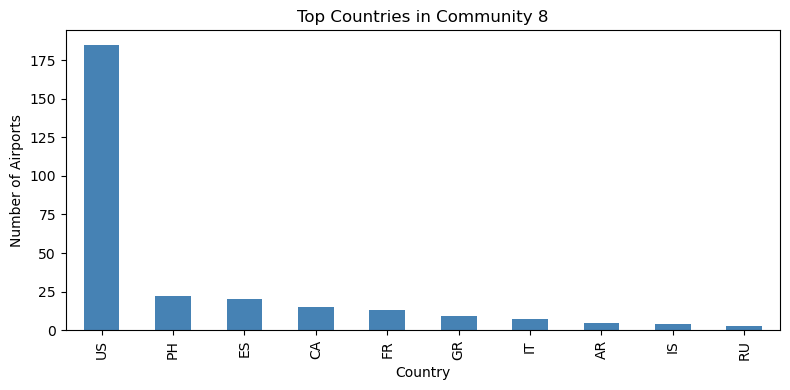

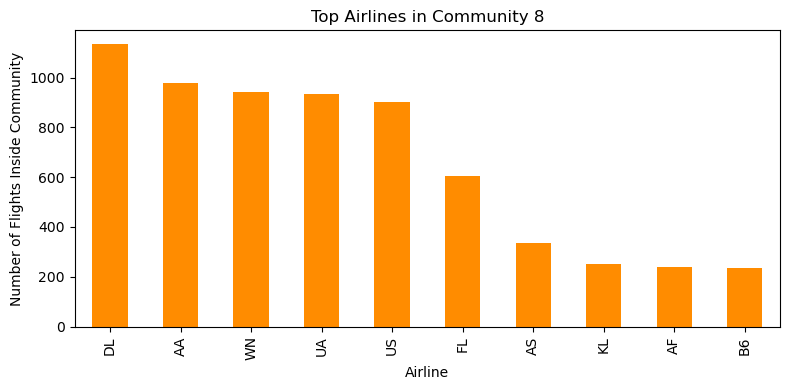

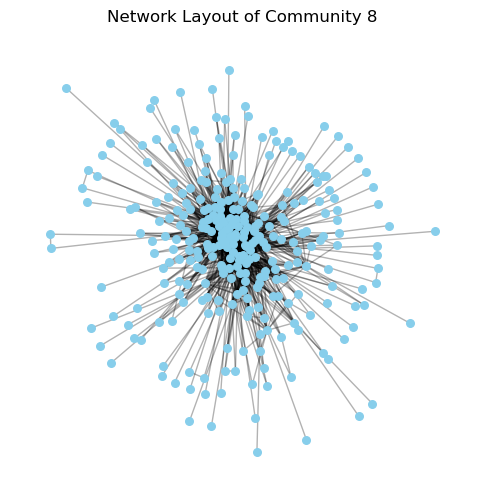


=== Visuals for Community 9 ===


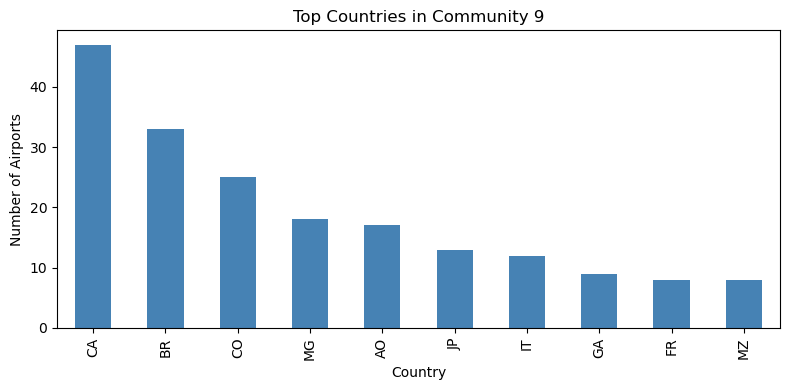

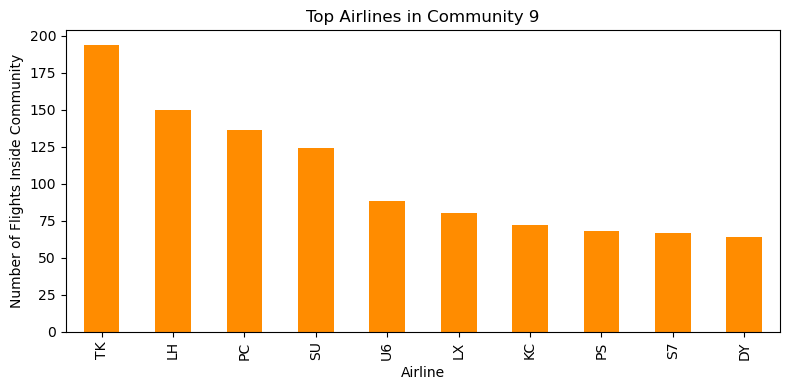

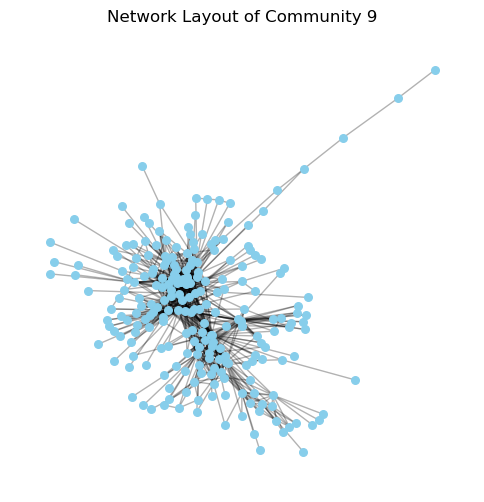


=== Visuals for Community 6 ===


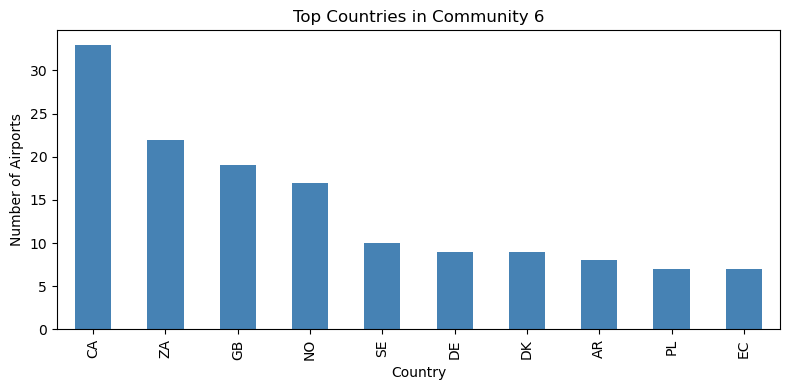

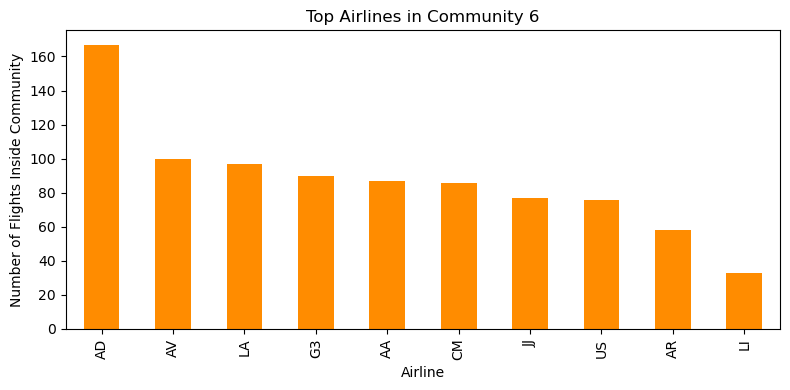

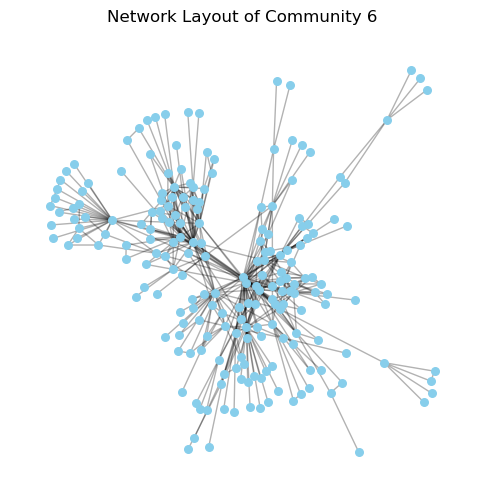


=== Visuals for Community 18 ===


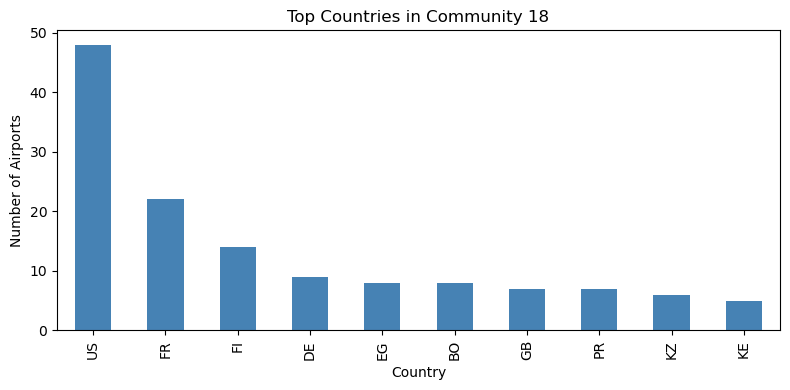

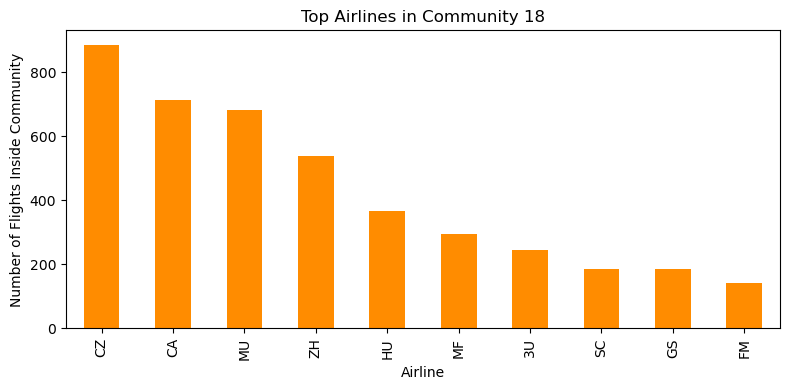

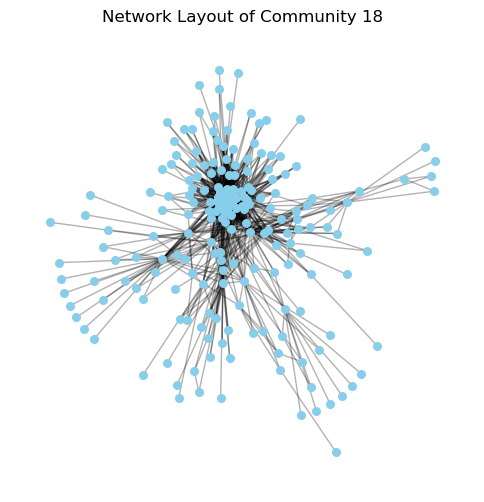


=== Visuals for Community 10 ===


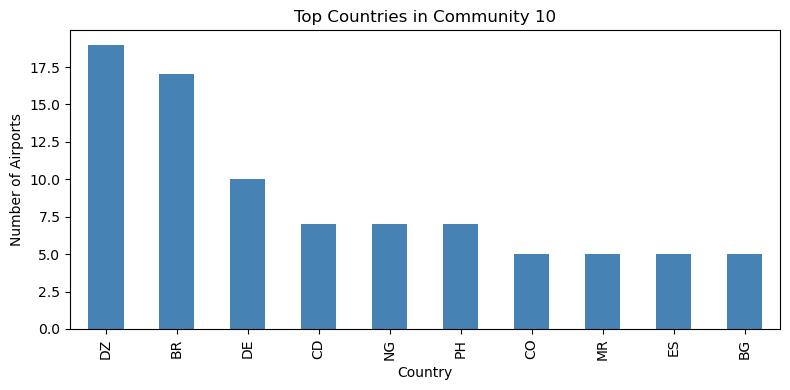

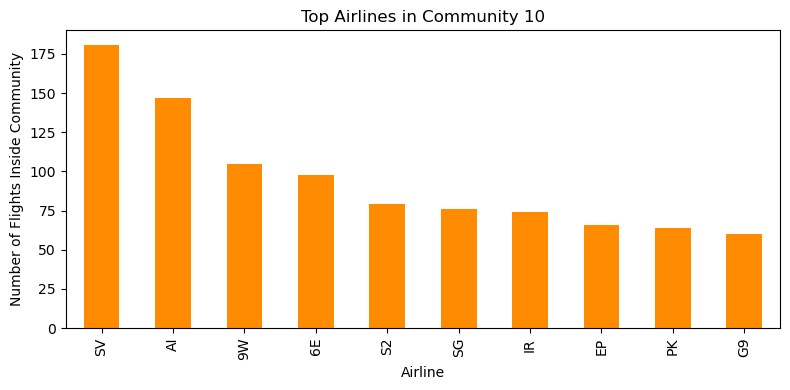

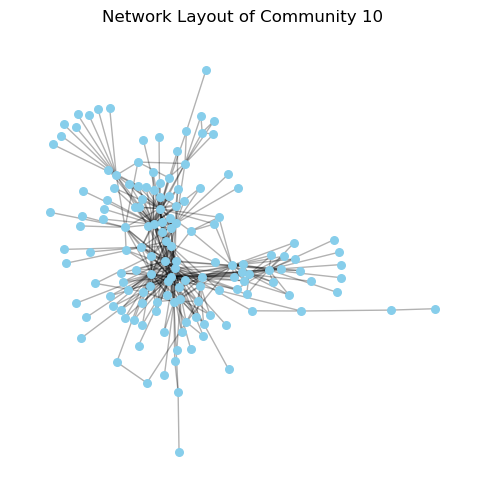

In [47]:
import matplotlib.pyplot as plt

# ==========================================================
# 5. VISUALIZATIONS FOR TOP 5 COMMUNITIES
# ==========================================================

def plot_top_countries(countries, cid):
    plt.figure(figsize=(8,4))
    countries.head(10).plot(kind='bar', color='steelblue')
    plt.title(f"Top Countries in Community {cid}")
    plt.ylabel("Number of Airports")
    plt.xlabel("Country")
    plt.tight_layout()
    plt.show()

def plot_top_airlines(airlines, cid):
    plt.figure(figsize=(8,4))
    airlines.head(10).plot(kind='bar', color='darkorange')
    plt.title(f"Top Airlines in Community {cid}")
    plt.ylabel("Number of Flights Inside Community")
    plt.xlabel("Airline")
    plt.tight_layout()
    plt.show()


# Very simple network visualization for each community
def plot_community_network(G_sub, cid):
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw_networkx_nodes(G_sub, pos, node_size=30, node_color="skyblue")
    nx.draw_networkx_edges(G_sub, pos, alpha=0.3)
    plt.title(f"Network Layout of Community {cid}")
    plt.axis("off")
    plt.show()


# Generate all plots for top 5 communities
for cid, data in community_results.items():
    print(f"\n=== Visuals for Community {cid} ===")
    plot_top_countries(data["countries"], cid)
    plot_top_airlines(data["airlines"], cid)
    plot_community_network(build_subgraph(G, data["airports_in_community"]), cid)



 INTERNAL ATTACK: COMMUNITY 8
Top internal hub removed: 3682 (MGW)
GCC before attack: 298
GCC after attack:  293
Components before: 1
Components after:  5
Robustness classification: ⭐ HIGH internal resilience


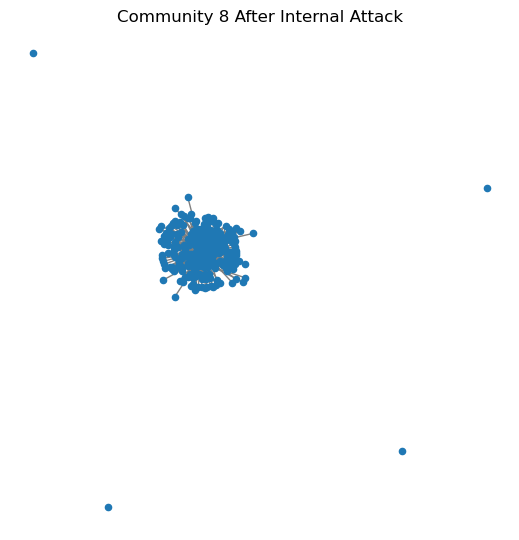


 INTERNAL ATTACK: COMMUNITY 9
Top internal hub removed: 1701 (YCY)
GCC before attack: 229
GCC after attack:  226
Components before: 1
Components after:  3
Robustness classification: ⭐ HIGH internal resilience


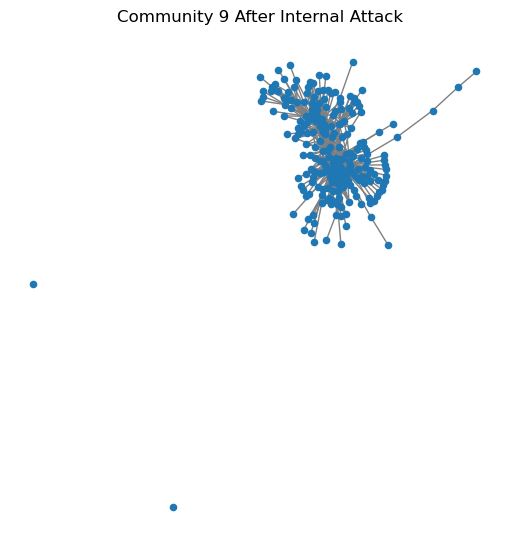


 INTERNAL ATTACK: COMMUNITY 6
Top internal hub removed: 3576 (HFD)
GCC before attack: 202
GCC after attack:  201
Components before: 1
Components after:  1
Robustness classification: ⭐ HIGH internal resilience


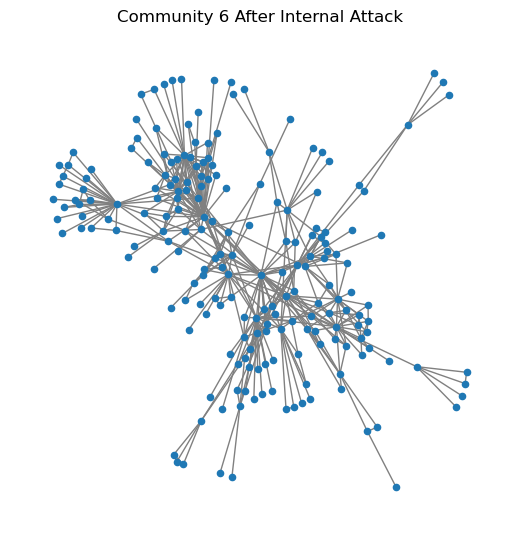


 INTERNAL ATTACK: COMMUNITY 18
Top internal hub removed: 3364 (ADW)
GCC before attack: 197
GCC after attack:  196
Components before: 1
Components after:  1
Robustness classification: ⭐ HIGH internal resilience


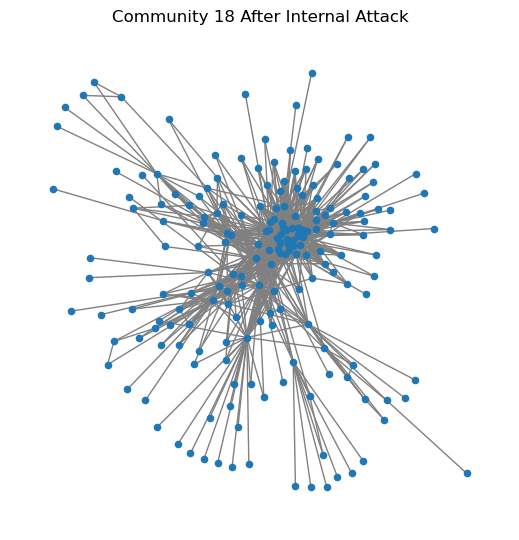


 INTERNAL ATTACK: COMMUNITY 10
Top internal hub removed: 2072 (CBH)
GCC before attack: 147
GCC after attack:  144
Components before: 1
Components after:  3
Robustness classification: ⭐ HIGH internal resilience


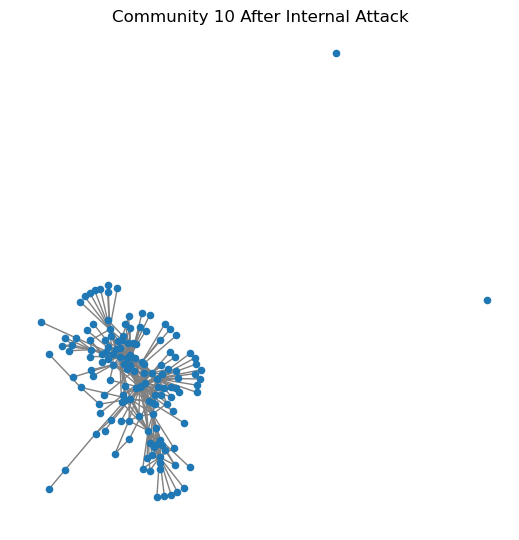

In [49]:
# ==========================================================
# COMMUNITY-LEVEL ATTACK SIMULATION
# ==========================================================

def internal_attack_simulation(G_sub, k=1):
    """
    Remove the top-k highest degree nodes inside the community
    and measure internal structural collapse.
    """
    # Identify top-k hubs
    degrees = dict(G_sub.degree())
    hubs = sorted(degrees, key=degrees.get, reverse=True)[:k]
    
    # Before attack
    GCC_before = len(max(nx.connected_components(G_sub), key=len))
    comps_before = nx.number_connected_components(G_sub)
    
    # Perform attack
    G_att = G_sub.copy()
    G_att.remove_nodes_from(hubs)
    
    # After attack
    if len(G_att.nodes()) > 0:
        GCC_after = len(max(nx.connected_components(G_att), key=len))
        comps_after = nx.number_connected_components(G_att)
    else:
        GCC_after = 0
        comps_after = 0
        
    return hubs, GCC_before, GCC_after, comps_before, comps_after, G_att


# ==========================================================
# APPLY TO TOP 5 COMMUNITIES
# ==========================================================

for cid, data in community_results.items():
    print(f"\n==========================")
    print(f" INTERNAL ATTACK: COMMUNITY {cid}")
    print("==========================")
    
    nodes = data["airports_in_community"]
    G_sub = build_subgraph(G, nodes)
    
    hubs, gcc_b, gcc_a, comp_b, comp_a, G_att = internal_attack_simulation(G_sub, k=1)
    
    # PRINT RESULTS
    print(f"Top internal hub removed: {hubs[0]} ({G.nodes[hubs[0]]['iata']})")
    print(f"GCC before attack: {gcc_b}")
    print(f"GCC after attack:  {gcc_a}")
    print(f"Components before: {comp_b}")
    print(f"Components after:  {comp_a}")
    
    # Robustness classification
    if gcc_a / gcc_b > 0.85:
        robustness = "HIGH internal resilience"
    elif gcc_a / gcc_b > 0.60:
        robustness = "MEDIUM internal resilience"
    else:
        robustness = "LOW internal resilience"
        
    print(f"Robustness classification: ⭐ {robustness}")
    
    # Optional: quick visual
    pos = nx.spring_layout(G_att, seed=42)
    plt.figure(figsize=(5,5))
    nx.draw(G_att, pos, node_size=20, edge_color="gray")
    plt.title(f"Community {cid} After Internal Attack")
    plt.axis("off")
    plt.show()
